# 🧠 03 · 3인자 학습과 R-STDP

01편에서 뉴런 하나가 스파이크를 내는 법을, 02편에서 두 뉴런의 발화 타이밍만으로 시냅스가 스스로 바뀌는 **STDP**를 봤습니다. STDP는 "함께 발화하면 강해진다"는 상관을 학습하지만, **무엇이 좋은 행동인지(보상)** 를 향해 배우지는 못합니다. 이번 편은 여기에 **세 번째 인자**(보상·신경조절 신호)를 더한 **3인자 학습**과 그 대표 형태 **R-STDP**를 다룹니다. 정답 라벨 없이 **보상만으로** 과제를 배우는 것을 직접 구현합니다.

## 이번 편에서 배우는 것
1. STDP의 pre·post 상관을 **자격 흔적(eligibility trace)** 으로 정식화하고, 그 시간상수가 **지연 보상**을 어떻게 견디는지 본다.
2. **pre 흔적**이 어떻게 자격의 재료가 되는지 이해한다.
3. **R-STDP**로 보상만으로 Go/No-Go 분류를 배우고, 이어서 출력이 여러 개일 때 **어느 행동에 credit을 줄지**(credit assignment)를 정책경사식으로 해결한다.

## 0. 개발 환경

환경 설정은 01편과 같습니다. 아래 셀에서 라이브러리를 불러오고 재현성(시드)·그림 설정을 맞춥니다.

In [1]:
import torch
import snntorch as snn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)   # 재현성: 난수 시드 고정

# 한글 폰트 (macOS). 라벨이 네모로 깨지면 'AppleSDGothicNeo' 로 바꿔보세요.
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
device = torch.device("cpu")              # 작은 모델이라 CPU로 충분
print("torch version:", torch.__version__, "| snntorch version:", snn.__version__)

torch version: 2.12.1 | snntorch version: 1.0.0


## 1. STDP에서 3인자로

02편의 STDP는 **pre가 먼저, post가 나중**에 발화하면 그 연결을 강화했습니다. 두 뉴런의 활동만 보는 **2인자(pre·post) 규칙**입니다. 하지만 이걸로는 "이 행동이 **좋았는지**"를 배울 수 없습니다 — 상관은 알아도 보상은 모르니까요.

**3인자 학습**은 여기에 세 번째 인자 $M(t)$(보상·신경조절 신호)를 곱합니다.

$$ \underbrace{\Delta w_{ij}}_{\text{가중치 변화}} = \eta \cdot \underbrace{M(t)}_{\text{③ 보상/신경조절}} \cdot \underbrace{e_{ij}(t)}_{\text{①×② 자격 흔적}} $$

### 기호 정리
- **$\Delta w_{ij}$**: 입력 뉴런 $i$ → 출력 뉴런 $j$ 시냅스 가중치의 변화량.
- **$\eta$ (에타)**: 학습률. 한 번에 얼마나 크게 바꿀지.
- **$M(t)$**: 세 번째 인자. 도파민 같은 전역 신호로 보통 보상에서 옵니다. "지금 실제로 바꿔라(그리고 어느 방향으로)"는 게이트.
- **$e_{ij}(t)$**: **자격 흔적(eligibility trace)**. "이 시냅스가 바뀔 *자격*이 있다"는 임시 표식.
- **$\text{pre}_i,\ \text{post}_j$**: 입력 뉴런 $i$·출력 뉴런 $j$의 활동(스파이크 또는 그 흔적).

### 정식화: 자격은 ①×②, 변화는 ×③
pre·post의 곱을 즉시 가중치에 반영하지 않고, **자격 흔적에 쌓아 두고** 감쇠시킵니다.

$$ e_{ij}(t) = \gamma_e\, e_{ij}(t-1) + \text{pre}_i(t)\cdot\text{post}_j(t) $$

- 오른쪽 둘째 항이 **①×②**입니다: pre와 post가 함께 활동한 순간 자격이 적립됩니다(STDP의 상관과 같은 재료).
- $\gamma_e \in (0,1)$: 적립된 자격이 매 스텝 남는 비율. 자격은 이 비율대로 서서히 식습니다.

세 번째 인자가 도착하면 그때 쌓인 자격을 실제 변화로 바꿉니다: $\Delta w_{ij} = \eta\, M(t)\, e_{ij}(t)$. 정리하면 **①×②가 "바뀔 자격"을 만들고, ③이 "실제로 바꿀지와 그 방향(+/−)"을 정합니다.**

### 왜 자격 흔적이 필요한가 — 지연 보상 문제
행동을 하고 **한참 뒤에야** 보상이 오는 경우가 많습니다(여러 행동을 한 뒤에야 성공/실패가 판명). 그 순간 "아까 어느 시냅스가 기여했지?"를 직접 알 수는 없습니다. 자격 흔적이 pre·post 상관을 **잠시 붙들어 두어**, 늦게 오는 보상과 과거 활동을 잇는 **다리**가 됩니다. 얼마나 오래 붙들 수 있는지는 $\gamma_e$가 정하는데, 다음 절에서 이걸 더 직관적인 **시간상수 $\tau_e$**로 바꿔 볼 것입니다.

## 2. 자격 흔적을 손으로 따라가기

시냅스 하나만 떼어 봅니다. $t=12$에 pre가, $t=14$에 post가 발화하면(pre가 먼저 → 자격 적립), 그 순간 자격 흔적 $e$에 양의 자격이 쌓이고 이후 **감쇠**합니다.

### 감쇠를 시간상수로 쓰기
앞 절의 $\gamma_e$는 "매 스텝 남는 비율"이었습니다. 그런데 정작 알고 싶은 건 "**몇 스텝이나 기억하나**"죠. 그래서 감쇠를 **시간상수 $\tau_e$**(단위: 스텝)로 다시 씁니다. 매 스텝 곱하는 감쇠 계수와 시간상수는 이렇게 이어집니다.

$$ \gamma_e = e^{-1/\tau_e} \qquad\Longleftrightarrow\qquad \tau_e = -\frac{1}{\ln \gamma_e} $$

- $\tau_e$가 크면 천천히 식어 **오래 기억**하고, 작으면 금방 잊습니다. 예를 들어 $\tau_e=10$이면 약 10스텝 뒤 흔적이 $1/e\approx 37\%$로 줄어듭니다.
- 01편 막전위의 누수 계수 $\beta$도 사실 같은 것입니다 — $\beta = e^{-1/\tau_m}$인 감쇠 계수였죠. "얼마나 오래 기억하나"가 핵심인 양은 시간상수 $\tau$로 두는 편이 직관적이라, 흔적에는 $\tau$를 씁니다.

**핵심**: 보상 $M$이 **언제 도착하느냐**에 따라 실제 변화 $\Delta w = \eta\,M\,e(t_r)$가 달라집니다. 흔적이 남아있는 동안 보상이 오면 학습되고, 너무 늦으면 흔적이 식어 학습이 안 됩니다. **$\tau_e$가 곧 "얼마나 지연된 보상까지 견디나"입니다.**

### 숫자로 따라가 보기
$\tau_e=10$이면 $\gamma_e = e^{-1/10} \approx 0.905$입니다. §1 점화식 $e(t)=\gamma_e\,e(t-1)+\text{pre}\cdot\text{post}$에서, pre→post 코인시던스가 완성되는 순간(post가 터지는 $t=14$)에 자격이 한 번 쌓이고 이후 감쇠하는 걸 따라가 봅니다. 여기서는 **새로 쌓이는 양을 $1.0$으로 두고**(이 크기가 실제로 어디서 오는지는 §3의 pre 흔적에서 다룹니다) 감쇠 자체에 집중합니다.

| 스텝 $t$ | 계산: $\gamma_e\,e(t-1) + (\text{새로 쌓임})$ | $e(t)$ |
|:--:|:--|:--:|
| 13 | – | 0.000 |
| 14 | $0.905\cdot 0 + 1.0$ (코인시던스 완성) | 1.000 |
| 15 | $0.905\cdot 1.000$ | 0.905 |
| 16 | $0.905\cdot 0.905$ | 0.819 |
| 17 | $0.905\cdot 0.819$ | 0.741 |
| $\vdots$ | | |
| 24 | (쌓인 지 10스텝 뒤 $=\tau_e$) | 0.368 |

쌓이는 순간 1로 튀고, 매 스텝 $0.905$를 곱해 기하급수적으로 감쇠합니다 — 10스텝($=\tau_e$) 뒤 약 $0.37\,(=1/e)$입니다. 보상이 이 곡선의 어디쯤 도착하느냐가 곧 $\Delta w$의 크기입니다.

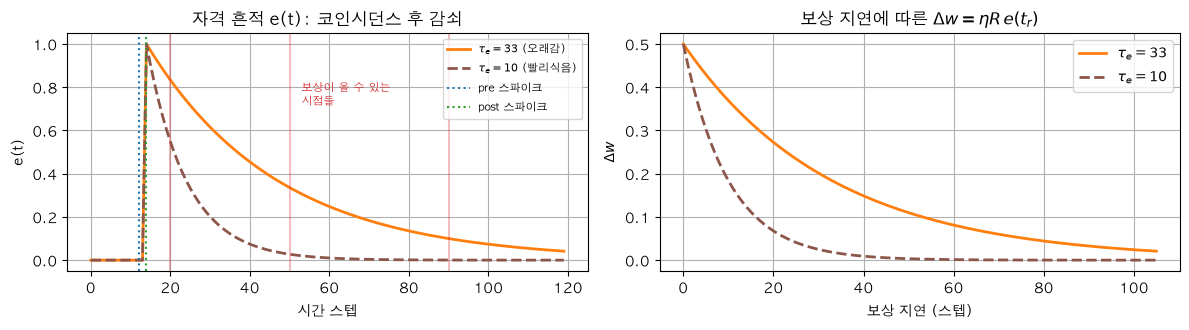

긴 흔적(tau_e=33)은 지연 40스텝에도 dw가 남지만, 짧은 흔적(tau_e=10)은 거의 0 -> tau_e가 '기다릴 수 있는 시간'을 정한다.


In [2]:
T = 120
pre_t, post_t = 12, 14           # pre가 먼저 발화 → 자격 형성 (STDP상 강화 방향)
A_e = 1.0                        # 코인시던스에서 새로 쌓이는 자격 크기 (§1의 pre·post; 여기선 1로 고정)

def eligibility(tau_e):
    # 자격 흔적 e(t): 코인시던스 완성(post 발화) 순간 A_e 만큼 쌓고, 이후 시간상수 tau_e로 감쇠.
    #   감쇠 계수 gamma = exp(-1/tau_e) = 매 스텝 곱하는 0~1 값.
    gamma = np.exp(-1.0 / tau_e)
    e = np.zeros(T)
    for t in range(1, T):
        e[t] = gamma * e[t-1]        # 감쇠
        if t == post_t:              # pre->post 코인시던스 완성 순간 자격 쌓임
            e[t] += A_e
    return e

e_long  = eligibility(33.0)          # tau_e 큼  -> 오래 기억
e_short = eligibility(10.0)          # tau_e 작음 -> 빨리 식음

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(e_long,  color="tab:orange", lw=2, label=r"$\tau_e=33$ (오래감)")
ax[0].plot(e_short, color="tab:brown",  lw=2, ls="--", label=r"$\tau_e=10$ (빨리식음)")
ax[0].axvline(pre_t,  color="tab:blue",  ls=":", label="pre 스파이크")
ax[0].axvline(post_t, color="tab:green", ls=":", label="post 스파이크")
for tr in [20, 50, 90]:
    ax[0].axvline(tr, color="tab:red", alpha=0.3)
ax[0].text(53, 0.72, "보상이 올 수 있는\n시점들", color="tab:red", fontsize=8)
ax[0].set_title("자격 흔적 e(t): 코인시던스 후 감쇠")
ax[0].set_xlabel("시간 스텝"); ax[0].set_ylabel("e(t)"); ax[0].legend(fontsize=8)

# 보상 지연에 따른 dw = eta * R * e(도착 시점)
delays = np.arange(post_t, T)
eta, R = 0.5, 1.0
ax[1].plot(delays - post_t, eta*R*e_long[delays],  color="tab:orange", lw=2, label=r"$\tau_e=33$")
ax[1].plot(delays - post_t, eta*R*e_short[delays], color="tab:brown",  lw=2, ls="--", label=r"$\tau_e=10$")
ax[1].set_title(r"보상 지연에 따른 $\Delta w = \eta R\, e(t_r)$")
ax[1].set_xlabel("보상 지연 (스텝)"); ax[1].set_ylabel(r"$\Delta w$"); ax[1].legend()
plt.tight_layout(); plt.show()
print("긴 흔적(tau_e=33)은 지연 40스텝에도 dw가 남지만, 짧은 흔적(tau_e=10)은 거의 0",
      "-> tau_e가 '기다릴 수 있는 시간'을 정한다.")

### 🔎 그림 읽기
- **왼쪽**: 두 흔적 모두 $t=14$에 1로 튄 뒤 감쇠하지만, $\tau_e=33$은 완만하게, $\tau_e=10$은 가파르게 식습니다. 옅은 빨간 세로선(보상이 올 수 있는 시점)에서의 흔적 높이가 곧 그때 학습될 양입니다.
- **오른쪽**: 보상 지연에 따른 $\Delta w = \eta R\, e(t_r)$. $\tau_e=33$은 40스텝 지연에도 $\Delta w$가 꽤 남지만, $\tau_e=10$은 금세 0에 가까워집니다. **$\tau_e$가 "기다릴 수 있는 시간"을 정합니다** — 지연 보상이 흔적이 식기 전에 와야 학습됩니다.

## 3. pre 흔적: 자격의 재료

앞에서 "코인시던스 순간 자격이 적립된다"고 했는데, 실제로 그 ①×②를 만들려면 각 입력 뉴런의 **최근 활동을 기억하는 흔적** $x_i(t)$가 필요합니다. 스파이크가 올 때마다 훅 오르고 이후 감쇠합니다.

$$ x_i(t) = e^{-1/\tau_{pre}}\, x_i(t-1) + \text{pre}_i(t) $$

- $\tau_{pre}$: pre 흔적의 시간상수(§2의 $\tau_e$와 같은 방식). 클수록 과거 스파이크를 오래 기억합니다.
- $\text{pre}_i(t)$: 시각 $t$에 입력 뉴런 $i$가 스파이크했으면 1, 아니면 0.

**왜 필요한가.** 출력 뉴런의 스파이크는 입력이 온 뒤 **조금 늦게** 터질 수 있습니다. "지금 이 순간 입력이 있나?"만 보면 방금 지나간 입력의 공을 놓칩니다. 이 흔적이 "방금까지 어떤 입력이 활동했다"는 짧은 기억을 남겨, 출력이 나중에 발화해도 **누구 덕분에 터졌는지를 시간차를 두고 연결**합니다. 출력이 스파이크한 순간의 pre 흔적을 자격에 더하면 — $e_i \mathrel{+}= x_i(t)\cdot\text{post}(t)$ — 그것이 곧 §1의 자격 흔적입니다.

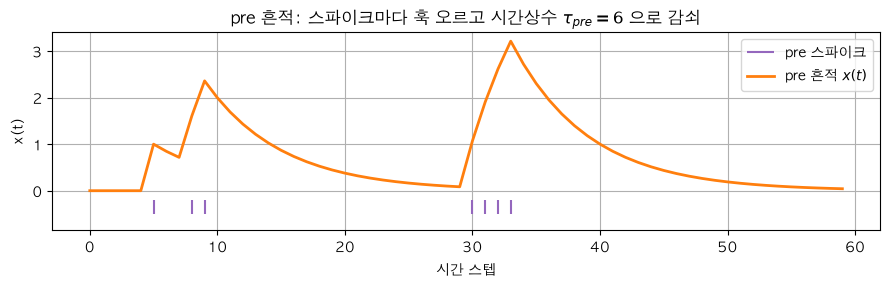

연속 스파이크(30~33)에서는 감쇠보다 적립이 빨라 흔적이 계단처럼 쌓인다.


In [3]:
tau_pre = 6.0                            # pre 흔적 시간상수 (스텝)
gamma_pre = np.exp(-1.0 / tau_pre)       # 매 스텝 곱하는 감쇠 계수 ≈ 0.846
spk_train = torch.zeros(60)
spk_train[[5, 8, 9, 30, 31, 32, 33]] = 1.0   # 두 번의 스파이크 버스트

x, trace = 0.0, []
for t in range(60):
    x = gamma_pre * x + spk_train[t].item()  # 스파이크에 +1, 매 스텝 gamma_pre 곱해 감쇠
    trace.append(x)

fig, ax = plt.subplots(figsize=(9, 3))
ax.eventplot(np.where(spk_train.numpy() > 0)[0], colors="tab:purple",
             lineoffsets=-0.35, linelengths=0.3, label="pre 스파이크")
ax.plot(trace, color="tab:orange", lw=2, label=r"pre 흔적 $x(t)$")
ax.set_title(r"pre 흔적: 스파이크마다 훅 오르고 시간상수 $\tau_{pre}=6$ 으로 감쇠")
ax.set_xlabel("시간 스텝"); ax.set_ylabel("x(t)"); ax.legend()
plt.tight_layout(); plt.show()
print("연속 스파이크(30~33)에서는 감쇠보다 적립이 빨라 흔적이 계단처럼 쌓인다.")

## 4. R-STDP ①: 보상으로 Go/No-Go 배우기

이제 자격 흔적과 세 번째 인자를 묶어, **정답 라벨 없이 보상만으로** 실제 과제를 배워 봅니다. **Go/No-Go**는 두 자극을 구별해 한쪽(Go)엔 반응하고 다른 쪽(No-Go)엔 반응을 억제하는 신경과학의 표준 행동 과제입니다. 목표는 출력 뉴런이 **GO 자극엔 발화, NOGO 자극엔 침묵**하도록 만드는 것입니다.

**자극의 표현.** 서로 다른 자극을 서로 다른 입력 뉴런 집단의 활동으로 부호화합니다(population coding). 입력 뉴런 20개를 두 그룹으로 나눕니다.
- 0–9번 = **GO 그룹**: 이 그룹이 활동하면 GO 자극.
- 10–19번 = **NOGO 그룹**: 이 그룹이 활동하면 NOGO 자극.

**시행(trial) 구조.** 매 시행마다 두 자극 중 하나를 무작위로 제시하고, 활성 그룹의 각 뉴런은 매 스텝 확률 `in_rate=0.5`로 독립 발화합니다(**포아송 과정**: 고정 확률의 무작위 스파이크 열). 나머지 그룹은 침묵합니다.

**보상 규칙.** 옳은 행동(GO에 발화 / NOGO에 침묵)이면 $R=+1$, 틀리면 $R=-1$. 가중치를 정답으로 직접 지도하지 않고, 이 전역 보상(세 번째 인자)만으로 GO 그룹 시냅스는 강화되고 NOGO 그룹 시냅스는 약화되도록 유도합니다.

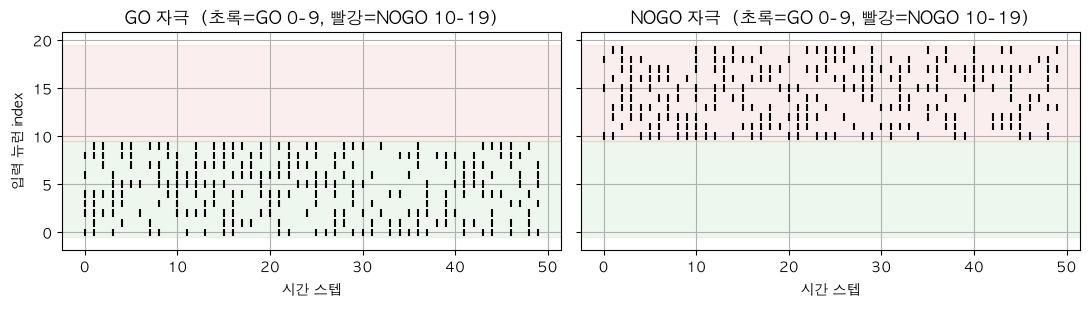

In [4]:
n_in = 20
T = 50            # 한 시행의 시간 스텝 수
in_rate = 0.5     # 활성 그룹의 포아송 발화 확률
go_slice   = slice(0, 10)
nogo_slice = slice(10, 20)

def make_input(stim):
    # stim='GO'면 0~9번, 'NOGO'면 10~19번 입력 뉴런이 포아송으로 발화.
    spk = torch.zeros(T, n_in)
    spk[:, go_slice if stim == "GO" else nogo_slice] = (torch.rand(T, 10) < in_rate).float()
    return spk

# 두 자극의 입력 래스터 비교
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for k, stim in enumerate(["GO", "NOGO"]):
    s = make_input(stim)
    rows = [np.where(s[:, i].numpy() > 0)[0] for i in range(n_in)]
    ax[k].eventplot(rows, colors="k", linelengths=0.8)
    ax[k].axhspan(-0.5, 9.5, color="tab:green", alpha=0.08)
    ax[k].axhspan(9.5, 19.5, color="tab:red", alpha=0.08)
    ax[k].set_title(f"{stim} 자극  (초록=GO 0-9, 빨강=NOGO 10-19)")
    ax[k].set_xlabel("시간 스텝")
ax[0].set_ylabel("입력 뉴런 index")
plt.tight_layout(); plt.show()

### 한 시행에서 일어나는 일
각 시행에서 자극을 $T$스텝 동안 출력 뉴런에 흘려보내며 다음을 계산합니다.
1. **입력 전류** $I(t) = \sum_i \text{pre}_i(t)\,w_i$ — 입력 스파이크 × 가중치의 합(01편에서 예고한 그 전류입니다).
2. **pre 흔적** $x_i(t) = e^{-1/\tau_{pre}}x_i(t-1)+\text{pre}_i(t)$ 를 유지하고, 출력이 스파이크하는 순간의 pre 흔적을 **자격 흔적**에 더합니다: $e_i \mathrel{+}= x_i(t)\cdot S_\text{out}(t)$.
3. 출력 뉴런에 약한 **탐험 잡음** 전류를 넣어, 가끔 다르게 행동해 보고 그 결과(보상)로 배우게 합니다.

자격 흔적은 pre·post의 곱이라 **항상 $\ge 0$**입니다. 가중치를 **키울지 줄일지의 부호는 오로지 세 번째 인자** $M=R-\bar R$ 가 정합니다.

In [5]:
# --- 학습 하이퍼파라미터 ---
beta        = 0.85    # 출력 LIF 누수 계수 (01편의 β, 감쇠 계수)
threshold   = 1.0
tau_pre     = 10.0    # pre 흔적 시간상수(스텝); 감쇠 계수 = exp(-1/tau_pre) ≈ 0.905
lr          = 0.01    # 학습률 eta
w_max       = 0.6     # 가중치 상한 (0~w_max 로 제한)
noise_std   = 0.15    # 탐험용 잡음 전류의 크기
fire_thresh = 3       # 한 시행 출력 스파이크가 이 이상이면 '반응했다'고 판정

gamma_pre = np.exp(-1.0 / tau_pre)
lif = snn.Leaky(beta=beta, threshold=threshold, reset_mechanism="subtract")

def run_trial(spk_in, w, learn_noise=True):
    # 한 시행 시뮬레이션.
    #   입력: spk_in [T, n_in] 입력 스파이크, w [n_in] 가중치, learn_noise(탐험 잡음 여부)
    #   반환: (elig [n_in] 자격 흔적, n_out 총 출력 스파이크 수, spk_rec [T] 출력 스파이크 열)
    mem  = torch.zeros(1)
    x    = torch.zeros(n_in)   # pre 흔적
    elig = torch.zeros(n_in)   # 자격 흔적 = sum_t (pre 흔적) x (post 스파이크)
    spk_rec = []
    for t in range(T):
        cur = (spk_in[t] * w).sum().reshape(1)          # 입력 전류 I = 스파이크 x 가중치의 합
        if learn_noise:
            cur = cur + noise_std * torch.randn(1)       # 탐험용 잡음
        spk, mem = lif(cur, mem)
        x = gamma_pre * x + spk_in[t]                    # pre 흔적 갱신
        elig = elig + x * spk                            # 출력 스파이크 순간의 pre 흔적을 누적
        spk_rec.append(spk.item())
    return elig, int(sum(spk_rec)), np.array(spk_rec)

print("run_trial 준비 완료.")

run_trial 준비 완료.


### 숫자로 따라가 보기 — 한 시행의 $\Delta w$
한 입력–한 출력만 놓고, 간단히 $\gamma_{pre}=0.8$로 짧은 시행을 따라가 봅니다(입력이 $t=1,2$에, 출력이 $t=3$에 발화).

| $t$ | pre | $x(t)=0.8\,x(t{-}1)+\text{pre}$ | post | 누적 $e \mathrel{+}= x\cdot\text{post}$ |
|:--:|:--:|:--|:--:|:--:|
| 1 | 1 | $0.8\cdot 0+1=1.00$ | 0 | 0 |
| 2 | 1 | $0.8\cdot 1.00+1=1.80$ | 0 | 0 |
| 3 | 0 | $0.8\cdot 1.80=1.44$ | 1 | $+1.44 \Rightarrow e=1.44$ |
| 4 | 0 | $0.8\cdot 1.44=1.15$ | 0 | 1.44 |

시행이 끝나면 자격 $e=1.44$. 보상 $R=+1$, 기대 보상 $\bar R=0$이면 $M=R-\bar R=1$이라
$$ \Delta w = \eta\,M\,e = 0.03\cdot 1\cdot 1.44 \approx 0.043\ (\text{강화}). $$
틀려서 $R=-1$이면 $\Delta w\approx-0.043$(약화). $e$는 늘 $\ge 0$이므로 **부호는 오직 $M$이 정합니다.**

(실제 코드는 시행이 길어 자격이 $T$에 비례해 커지므로, 업데이트에 자격의 **시행 평균** $e/T$를 씁니다 — 규칙의 형태와 부호는 위와 똑같습니다.)

### 학습 루프와 보상 예측 오차(RPE)
수백 시행을 반복하며 매 시행 세 번째 인자 규칙을 적용합니다.

$$ \Delta w = \eta\,(R-\bar R)\,e, \qquad \bar R \leftarrow 0.95\,\bar R + 0.05\,R $$

- $\bar R$ 는 최근 **기대 보상**(이동평균)이고, $M=R-\bar R$ 는 **"기대보다 얼마나 좋았나"**, 즉 **보상 예측 오차(RPE, reward prediction error)** 입니다.
- 예상보다 좋으면($M>0$) 방금 활동한 시냅스를 강화, 나쁘면($M<0$) 약화합니다. 항상 ±1인 날것의 $R$을 그대로 쓰면 업데이트가 과격해 불안정하지만, $\bar R$을 빼면 안정됩니다(뒤 "직접 바꿔보면 좋은 것"에서 확인).
- 이는 **도파민 뉴런이 보상 자체가 아니라 보상 예측 오차를 내보내는 것**과 같은 원리입니다 — 기대한 보상엔 반응이 약하고, 예상 밖 보상에 크게 반응합니다.

In [6]:
n_trials = 300

w = torch.full((n_in,), 0.15)   # 모든 시냅스 동일 초기화
w_init = w.clone()              # 학습 전 가중치 (before/after 비교용)
baseline = 0.0                  # 기대 보상 R_bar

hist = {"correct": [], "w_go": [], "w_nogo": []}
for tr in range(n_trials):
    stim = "GO" if torch.rand(1).item() < 0.5 else "NOGO"
    spk_in = make_input(stim)
    elig, n_out, _ = run_trial(spk_in, w, learn_noise=True)

    responded = n_out >= fire_thresh
    correct = responded if stim == "GO" else (not responded)
    R = 1.0 if correct else -1.0

    # ★ 3인자 업데이트: dw = eta * (R - baseline) * (자격의 시행 평균 e/T)
    w = (w + lr * (R - baseline) * elig / T).clamp(0.0, w_max)
    baseline = 0.95 * baseline + 0.05 * R                    # 기대 보상 갱신

    hist["correct"].append(float(correct))
    hist["w_go"].append(w[go_slice].mean().item())
    hist["w_nogo"].append(w[nogo_slice].mean().item())

print(f"마지막 100시행 정확도: {np.mean(hist['correct'][-100:]):.2f}")
print(f"최종 GO 그룹 평균 가중치: {w[go_slice].mean():.3f}  |  NOGO 그룹: {w[nogo_slice].mean():.3f}")

마지막 100시행 정확도: 1.00
최종 GO 그룹 평균 가중치: 0.600  |  NOGO 그룹: 0.011


### 결과: 보상만으로 가중치가 갈라졌나
세 그림으로 확인합니다. ① GO/NOGO 그룹 평균 가중치의 분리, ② 정확도(25시행 이동평균), ③ 최종 입력 뉴런별 가중치. **NOGO 막대가 거의 0으로 사라졌다면** NOGO 시냅스가 사실상 제거돼(그 자극에 반응 안 함) 학습이 성공한 것입니다.

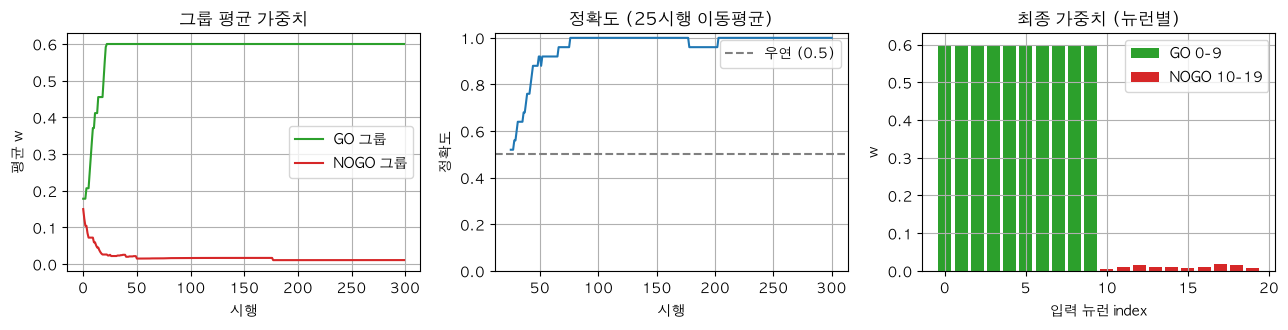

In [7]:
def sliding(a, k=25):
    a = np.array(a); return np.convolve(a, np.ones(k)/k, mode="valid")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].plot(hist["w_go"],  color="tab:green", label="GO 그룹")
ax[0].plot(hist["w_nogo"], color="tab:red",  label="NOGO 그룹")
ax[0].set_title("그룹 평균 가중치"); ax[0].set_xlabel("시행"); ax[0].set_ylabel("평균 w"); ax[0].legend()

sl = sliding(hist["correct"], 25)
ax[1].plot(np.arange(len(sl)) + 25, sl, color="tab:blue")
ax[1].axhline(0.5, ls="--", c="gray", label="우연 (0.5)")
ax[1].set_ylim(0, 1.02); ax[1].set_title("정확도 (25시행 이동평균)")
ax[1].set_xlabel("시행"); ax[1].set_ylabel("정확도"); ax[1].legend()

ax[2].bar(range(10),    w[go_slice].numpy(),   color="tab:green", label="GO 0-9")
ax[2].bar(range(10,20), w[nogo_slice].numpy(), color="tab:red",   label="NOGO 10-19")
ax[2].set_title("최종 가중치 (뉴런별)"); ax[2].set_xlabel("입력 뉴런 index"); ax[2].set_ylabel("w"); ax[2].legend()
plt.tight_layout(); plt.show()

### 학습 전 vs 후: 출력 반응 비교
가중치 숫자만으론 감이 안 오니, 초기 가중치 $w_{init}$와 학습된 $w$로 각각 GO/NOGO 자극을 주고 출력 스파이크를 비교합니다(잡음 없이 깨끗하게, `learn_noise=False`). 기대: **학습 전엔 둘 다 발화 → 학습 후엔 GO에만 발화, NOGO엔 침묵.**

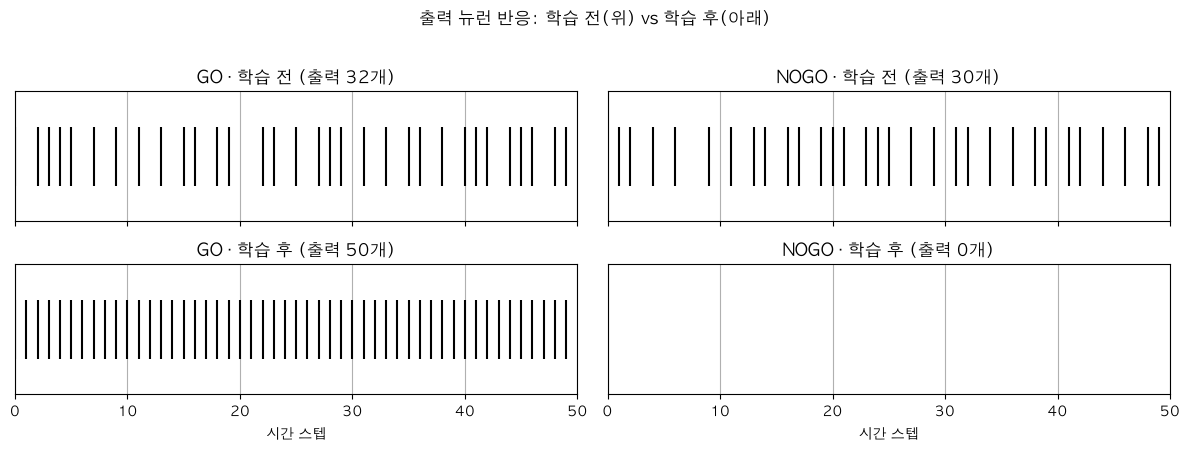

In [8]:
def out_raster(weights, stim):
    _, n_out, spk_rec = run_trial(make_input(stim), weights, learn_noise=False)
    return spk_rec, n_out

fig, ax = plt.subplots(2, 2, figsize=(12, 4.4), sharex=True)
for j, stim in enumerate(["GO", "NOGO"]):
    sr0, n0 = out_raster(w_init, stim)   # 학습 전
    sr1, n1 = out_raster(w, stim)        # 학습 후
    ax[0, j].eventplot(np.where(sr0 > 0)[0], colors="k", lineoffsets=0, linelengths=0.8)
    ax[1, j].eventplot(np.where(sr1 > 0)[0], colors="k", lineoffsets=0, linelengths=0.8)
    ax[0, j].set_title(f"{stim} · 학습 전 (출력 {n0}개)")
    ax[1, j].set_title(f"{stim} · 학습 후 (출력 {n1}개)")
    for i in range(2):
        ax[i, j].set_yticks([]); ax[i, j].set_xlim(0, T)
ax[1, 0].set_xlabel("시간 스텝"); ax[1, 1].set_xlabel("시간 스텝")
plt.suptitle("출력 뉴런 반응: 학습 전(위) vs 학습 후(아래)", y=1.02)
plt.tight_layout(); plt.show()

## 5. R-STDP ②: 여러 행동 중 고르기 (credit assignment)

Go/No-Go는 출력이 하나였습니다("반응하나 마나"). 실제 행동 선택은 **여러 후보 중 하나를 고르는** 문제죠. 여기서 새 어려움이 생깁니다: 보상이 왔을 때 **어느 행동의 시냅스에 공을 돌릴 것인가**(credit assignment)?

**과제.** 3개의 문맥(cue) 중 하나가 주어지면 3개의 행동 뉴런 중 **맞는 하나**를 골라야 합니다(정답 규칙: 큐 $c$ → 행동 $c$, 모델은 이 규칙을 모릅니다). 각 큐는 전용 입력 그룹 10개의 포아송 발화로 주어지고, 선택된 행동은 **시행 동안 가장 많이 발화한 뉴런**입니다. 보상 $R=\pm1$은 시행이 끝난 뒤 도착합니다.

**핵심 — credit은 실제로 선택한 행동에만.** 탐험 잡음 때문에 여러 행동 뉴런이 조금씩 발화하지만, 보상은 **실제로 고른 행동**의 결과입니다. 그래서 그 행동의 자격 흔적에만 세 번째 인자를 곱합니다(코드의 `mask`). 이는 강화학습의 **정책 경사(policy gradient, REINFORCE)** 와 같은 형태입니다 — 택한 행동을 보상 예측 오차 $(R-\bar R)$의 부호만큼 강화/약화하고, 자격 흔적이 "그 행동을 어떤 시냅스가 도왔나"를 이어 줍니다. mask 없이 모든 행동에 보상을 주면 어떻게 되는지는 5-2에서 직접 봅니다.

mask O — 평가 정확도(탐험 off): 1.00  (우연 = 0.33)


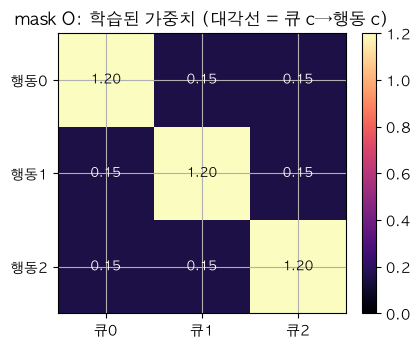

In [9]:
n_cue, per = 3, 10
n_in = n_cue * per; n_out = 3
in_rate, T = 0.5, 40
beta, threshold = 0.9, 1.0
tau_pre = 6.0                       # pre 흔적 시간상수 (스텝)
gamma_pre = np.exp(-1.0 / tau_pre)
lr, noise, w_max = 0.02, 0.4, 1.2   # 학습률 eta / 탐험 잡음 / 가중치 상한

lif = snn.Leaky(beta=beta, threshold=threshold, reset_mechanism="subtract")

def cue_input(c):
    # 큐 c의 전용 그룹(c*per ~ (c+1)*per)만 포아송 발화. 반환 [T, n_in].
    spk = torch.zeros(T, n_in)
    spk[:, c*per:(c+1)*per] = (torch.rand(T, per) < in_rate).float()
    return spk

def trial(c, w, explore=True):
    # 큐 c로 한 시행 실행. w [n_out, n_in].
    #   반환: (elig [n_out, n_in] 행동×입력 자격, counts [n_out] 행동별 스파이크 수)
    mems = torch.zeros(n_out); xpre = torch.zeros(n_in)
    elig = torch.zeros(n_out, n_in); counts = torch.zeros(n_out)
    spk_in = cue_input(c)
    for t in range(T):
        cur = (w * spk_in[t]).sum(1)                      # 행동 뉴런별 입력 전류 [n_out]
        if explore:
            cur = cur + noise * torch.randn(n_out)         # 탐험 잡음
        s, mems = lif(cur, mems)
        xpre = gamma_pre * xpre + spk_in[t]                # pre 흔적 [n_in]
        elig += s.unsqueeze(1) * xpre.unsqueeze(0)         # 외적: (행동 스파이크) ⊗ (pre 흔적) → [n_out, n_in]
        counts += s
    return elig, counts

def train(use_mask, n_trials=600, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)          # 두 조건(mask O/X)을 같은 난수로 공정 비교
    w = torch.full((n_out, n_in), 0.15); baseline = 0.0
    for tr in range(n_trials):
        c = np.random.randint(n_cue)
        elig, counts = trial(c, w, explore=True)
        action = int(counts.argmax()) if counts.max() > 0 else np.random.randint(n_out)
        R = 1.0 if action == c else -1.0
        if use_mask:
            mask = torch.zeros(n_out, 1); mask[action] = 1.0   # ③은 '선택한 행동'에만
            upd = elig * mask
        else:
            upd = elig                                         # (5-2 ablation) 모든 행동에 credit
        w = (w + lr * (R - baseline) * upd).clamp(0.0, w_max)
        baseline = 0.95 * baseline + 0.05 * R
    return w

def evaluate(w):                                          # 탐험 없이 큐→행동 정확도
    ok = []
    for c in range(n_cue):
        for _ in range(100):
            _, counts = trial(c, w, explore=False)
            a = int(counts.argmax()) if counts.max() > 0 else -1
            ok.append(a == c)
    return float(np.mean(ok))

w_mask = train(use_mask=True); ev_mask = evaluate(w_mask)
print(f"mask O — 평가 정확도(탐험 off): {ev_mask:.2f}  (우연 = 0.33)")

# 학습된 '행동 × 큐' 평균 가중치: 대각선이 강해야 (큐 c → 행동 c)
fig, ax = plt.subplots(figsize=(4.3, 3.6))
Wg = w_mask.reshape(n_out, n_cue, per).mean(2).numpy()
im = ax.imshow(Wg, cmap="magma", aspect="auto", vmin=0, vmax=w_max)
ax.set_xticks(range(n_cue)); ax.set_xticklabels([f"큐{c}" for c in range(n_cue)])
ax.set_yticks(range(n_out)); ax.set_yticklabels([f"행동{o}" for o in range(n_out)])
for o in range(n_out):
    for c in range(n_cue):
        ax.text(c, o, f"{Wg[o,c]:.2f}", ha="center", va="center",
                color="white" if Wg[o,c] < w_max*0.6 else "black", fontsize=9)
ax.set_title("mask O: 학습된 가중치 (대각선 = 큐 c→행동 c)")
plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()

### 🔎 그림 읽기 + 다음 질문
가중치 행렬의 **대각선**(큐 0→행동 0, 큐 1→행동 1, 큐 2→행동 2)만 강하고 나머지는 약합니다. 보상만으로 "각 큐엔 각 행동"이라는 규칙을 스스로 찾은 것입니다. (§4처럼 자격을 시행 평균으로 나누지 않고 원래 크기 + 작은 `lr`을 썼을 뿐, 규칙 $\Delta w=\eta M e$는 같습니다.)

그런데 credit을 **선택한 행동에만** 준 `mask`가 정말 필요할까요? mask를 빼고 **모든 행동의 자격**에 보상을 곱하면(즉 `upd = elig`) 어떻게 될까요? 같은 난수로 한 번 더 학습해 비교합니다.

mask X — 평가 정확도(탐험 off): 0.33  (우연 = 0.33)


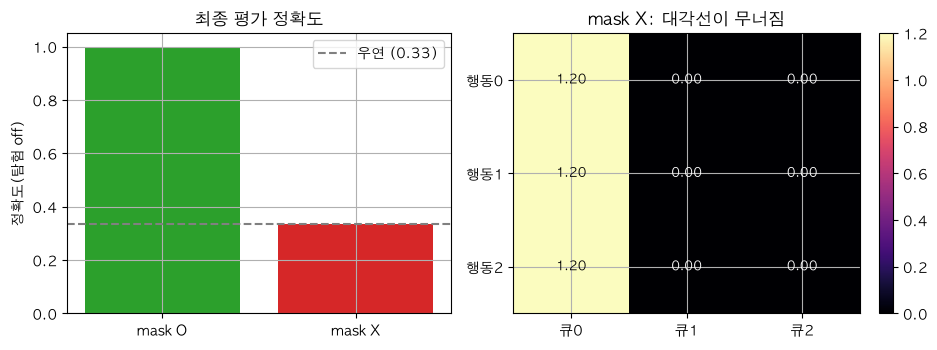

In [10]:
w_nomask = train(use_mask=False); ev_nomask = evaluate(w_nomask)   # mask 없이: 모든 행동에 credit
print(f"mask X — 평가 정확도(탐험 off): {ev_nomask:.2f}  (우연 = 0.33)")

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))
ax[0].bar(["mask O", "mask X"], [ev_mask, ev_nomask], color=["tab:green", "tab:red"])
ax[0].axhline(1/3, ls="--", c="gray", label="우연 (0.33)"); ax[0].set_ylim(0, 1.05)
ax[0].set_title("최종 평가 정확도"); ax[0].set_ylabel("정확도(탐험 off)"); ax[0].legend()

Wx = w_nomask.reshape(n_out, n_cue, per).mean(2).numpy()
im = ax[1].imshow(Wx, cmap="magma", aspect="auto", vmin=0, vmax=w_max)
ax[1].set_xticks(range(n_cue)); ax[1].set_xticklabels([f"큐{c}" for c in range(n_cue)])
ax[1].set_yticks(range(n_out)); ax[1].set_yticklabels([f"행동{o}" for o in range(n_out)])
for o in range(n_out):
    for c in range(n_cue):
        ax[1].text(c, o, f"{Wx[o,c]:.2f}", ha="center", va="center",
                   color="white" if Wx[o,c] < w_max*0.6 else "black", fontsize=9)
ax[1].set_title("mask X: 대각선이 무너짐")
plt.colorbar(im, ax=ax[1], fraction=0.046); plt.tight_layout(); plt.show()

### 🔎 그림 읽기 — 왜 mask가 필수인가
mask를 빼자 평가 정확도가 **우연(0.33)** 으로 주저앉고, 가중치 행렬의 대각선도 사라집니다. 탐험 때문에 매 시행 여러 행동이 조금씩 발화하는데, 보상을 **모든 행동의 자격**에 뿌리면 책임 없는 행동까지 똑같이 강화·약화돼 큐–행동 대응이 서지 않기 때문입니다.

이것이 **credit assignment**의 핵심입니다: 보상은 **실제로 취한 행동**에만 귀속시켜야 합니다. mask(택한 행동만) + baseline(기대보상 빼기)은 강화학습의 **정책 경사(REINFORCE)** 와 같은 형태이고, 자격 흔적이 "그 행동을 어떤 시냅스가 도왔나"를 이어 줍니다.

## 6. 정리 & 다음 단계

### 배운 것
- **3인자 규칙** $\Delta w = \eta\,M(t)\,e_{ij}$: ①×②(pre·post)가 **자격**을 만들고, ③(보상·신경조절 $M$)이 **게이트**한다.
- **자격 흔적**의 시간상수 $\tau_e$가 견딜 수 있는 **보상 지연**을 정한다 — distal reward 문제의 해법. **pre 흔적**이 그 자격의 재료다.
- **R-STDP**로 정답 라벨 없이 **보상만으로** Go/No-Go를 학습했다(학습 후 GO엔 발화, NOGO엔 침묵).
- 출력이 여럿일 땐 **credit을 실제 취한 행동에만** 줘야 한다(**정책 경사**). baseline $\bar R$을 빼 "기대보다 얼마나 좋았나"(**보상 예측 오차, RPE**)만 반영해 안정화한다.

### 직접 바꿔보면 좋은 것
- §5의 `noise`(탐험)를 `0.0`으로 → 탐험이 없으면 새 행동을 시도하지 못해 학습이 멈추는지.
- §4·§5에서 `baseline` 갱신을 끄고 $M=R$ 로만 학습 → 업데이트가 과격해져 불안정해지는지.
- §2의 $\tau_e$, §3·§4의 $\tau_{pre}$를 키우거나 줄여 → 견디는 보상 지연 / 학습 속도가 어떻게 변하는지.
- §4의 `lr`·`in_rate`를 낮춰 → 학습 곡선이 더 완만해지는지.

### R-STDP의 한계 → 다음 편(`04`)
R-STDP의 세 번째 인자는 **스칼라 보상 하나**입니다. 뉴런 수천 개짜리 깊은/순환 네트워크에서 "각 뉴런이 최종 오차에 *얼마나* 기여했나"라는 정교한 credit은 스칼라 보상만으로는 부족합니다.

**e-prop**은 자격 흔적(지역)은 그대로 두되, 세 번째 인자를 **과제 오차에서 유도한 뉴런별 learning signal**로 바꿉니다. 이 조합은 **BPTT(시간 역전파)의 지역·온라인 근사**로 유도됩니다. 다음 편에서 BPTT를 먼저 간단히 보고 e-prop으로 갑니다.